In [65]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  

Pole cut: excluding |latitude| > 60.0 deg (last 30.0 deg near each pole)


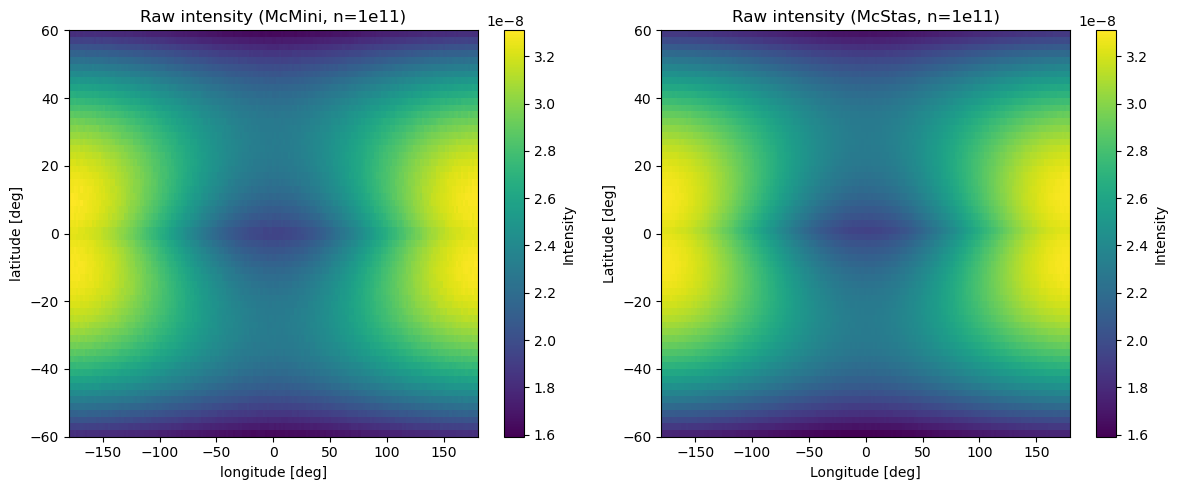

Total raw intensity (mcmini, n=1e11) = 2.681466e-04
Total raw intensity (McStas, n=1e11) = 2.680999e-04
Ratio of total raw intensities (mini/mcstas) = 1.0001741605e+00
Total cosine corrected intensity (mcmini, n=1e11) = 3.286245e-04
Total cosine corrected intensity (McStas, n=1e11) = 3.285604e-04
Ratio of total cosine corrected intensities (mini/mcstas) = 1.000195e+00


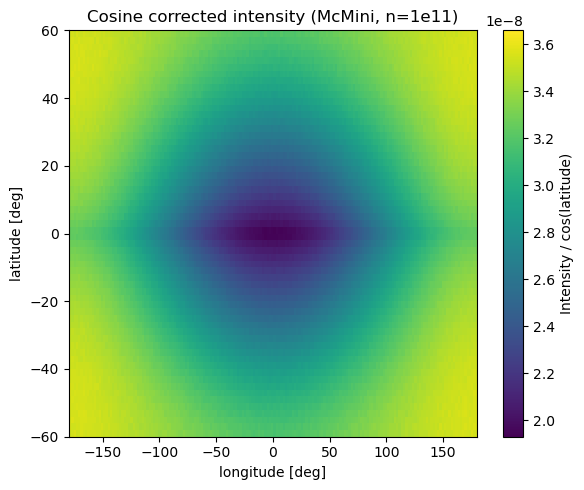

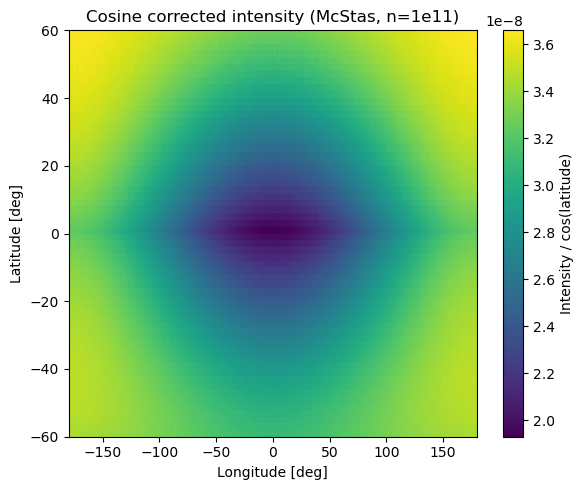

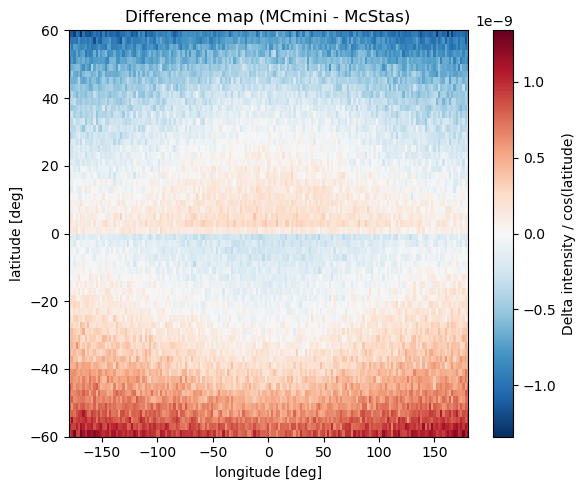

Mean residual for cosine-corrected difference map: 5.932948e-12
Mean absolute residual (cosine-corrected):         3.110601e-10
RMS residual (cosine-corrected):                   4.126713e-10
Mean pull (cosine-corrected):                      8.282055e-02
Pull std (cosine-corrected):                       5.084163e+00
Reduced chi^2 (cosine-corrected, before pole cut; N=16200 bins): 2.451969e+02
Reduced chi^2 (cosine-corrected, after 30.0 deg pole cut; N=10800 bins): 2.585557e+01


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_14020/4056369849.py:207: RuntimeWarning: Mean of empty slice
  lat_residual_mean = np.nanmean(diff_corr_masked, axis=1)
/opt/homebrew/Caskroom/miniconda/base/envs/mcstas/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


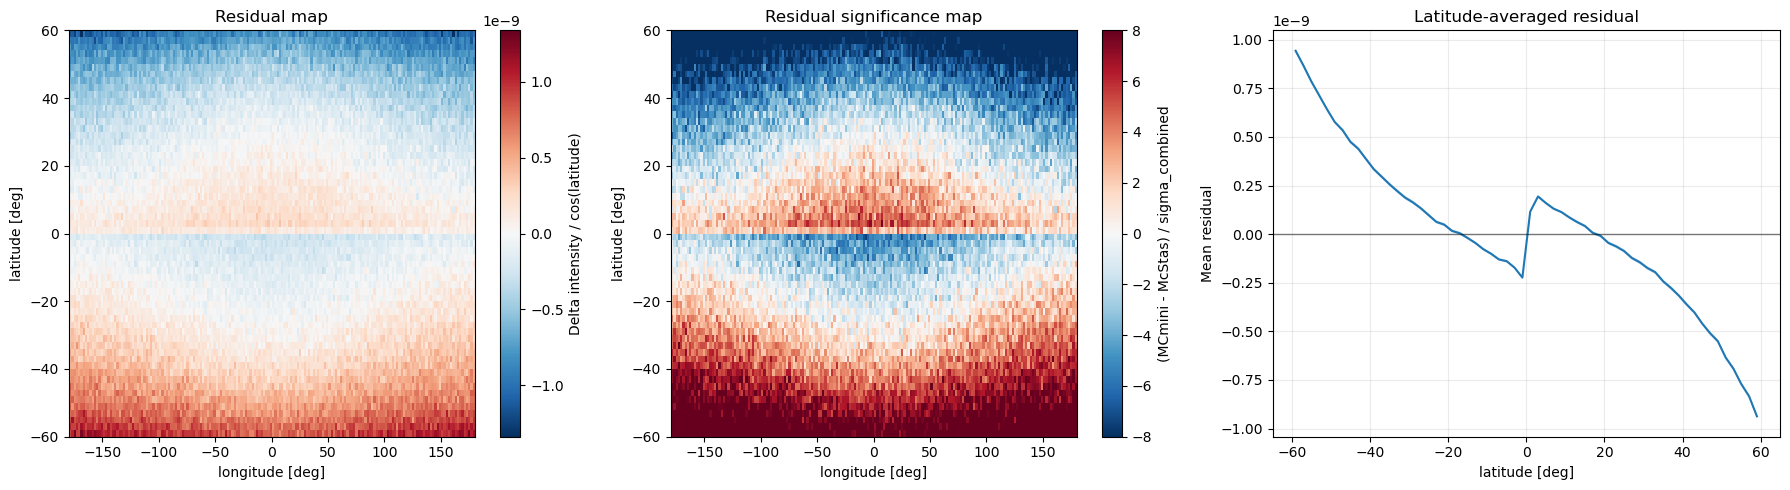

Residual RMS: 4.126713e-10
Mean |significance|: 4.087747


/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_14020/4056369849.py:257: RuntimeWarning: Mean of empty slice
  lat_residual_mean_raw = np.nanmean(diff_raw_masked, axis=1)


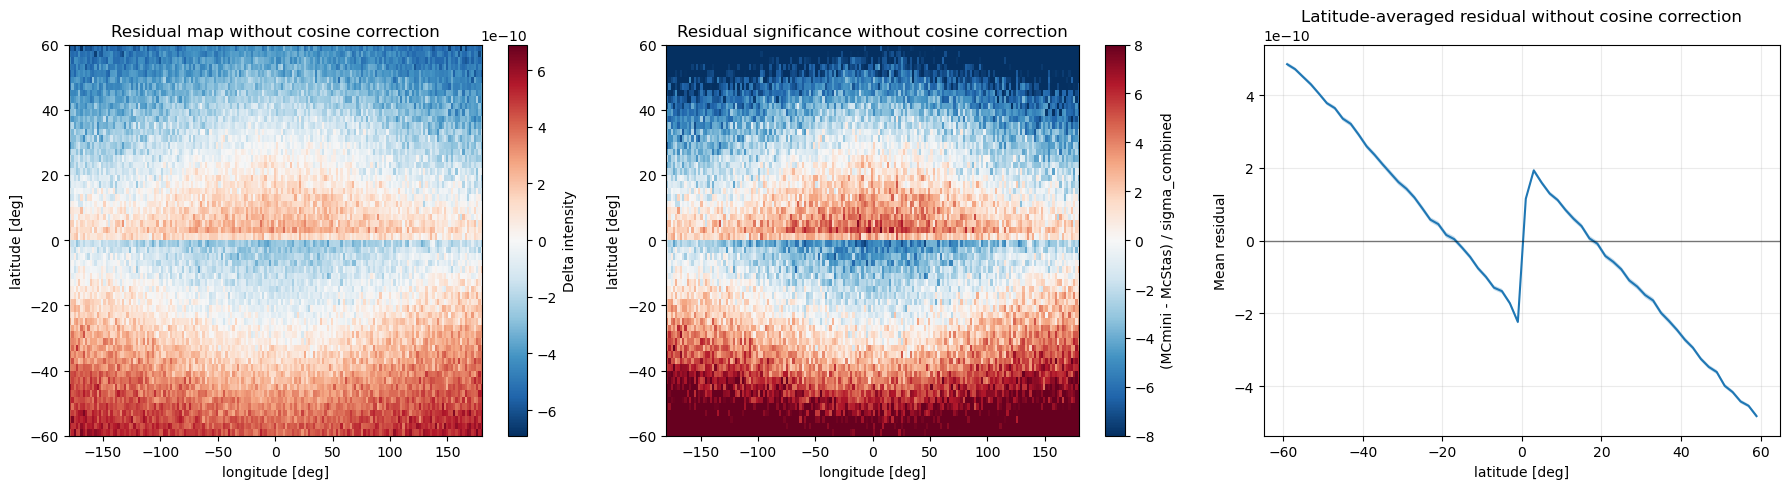

Raw residual RMS: 2.678545e-10
Raw mean |significance|: 4.087747
Reduced chi^2 (raw, before pole cut; N=16200 bins): 2.451969e+02
Reduced chi^2 (raw, after 30.0 deg pole cut; N=10800 bins): 2.585557e+01
Alignment scan on raw maps (lower RMS is better):
  lat_shift_-1 2.616119e-10
  lat_flip     2.671628e-10
  lon_flip     2.677836e-10
  none         2.678545e-10
  lon_shift_-1 2.851663e-10
  lon_shift_+1 2.856179e-10
  lat_shift_+1 7.671550e-10
Best candidate: lat_shift_-1 (RMS=2.616119e-10)


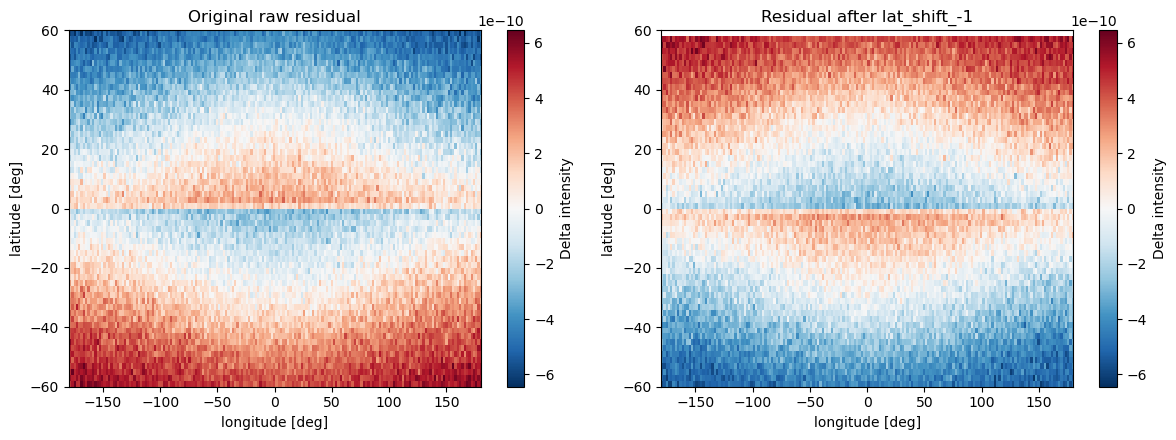

Total intensity (mcmini, n=1e11) = 0.00031487262545048015
Total intensity (McStas, n=1e11) = 0.00031487254071474143
Ratio of total intensities (mini/mcstas) = 1.0000002691112364
Using equator band centered at 0.0 deg with bin centers: [-1.  1.]


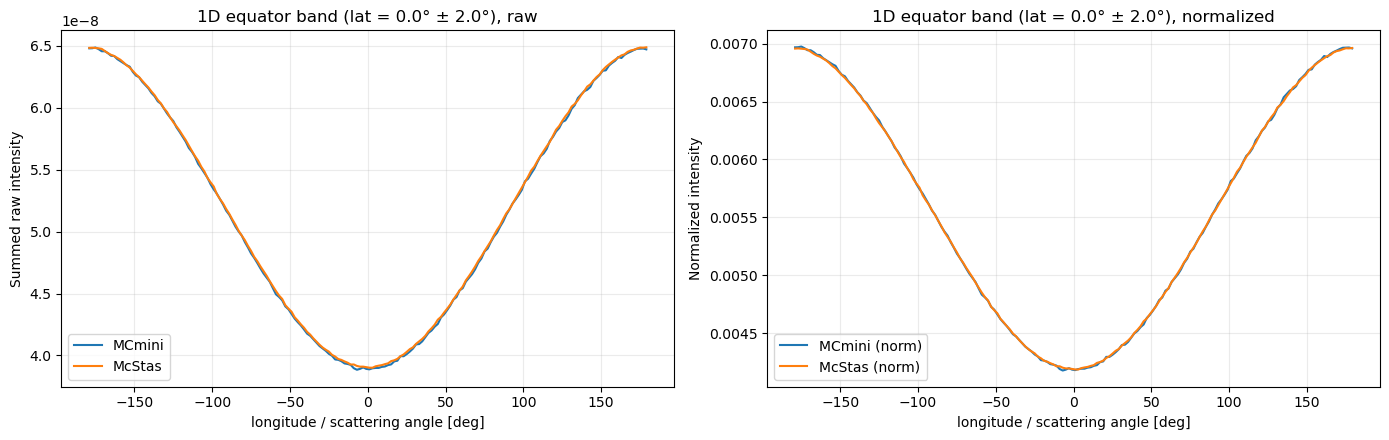

Using meridian band centered at 0.0 deg with bin centers: [-1.  1.]


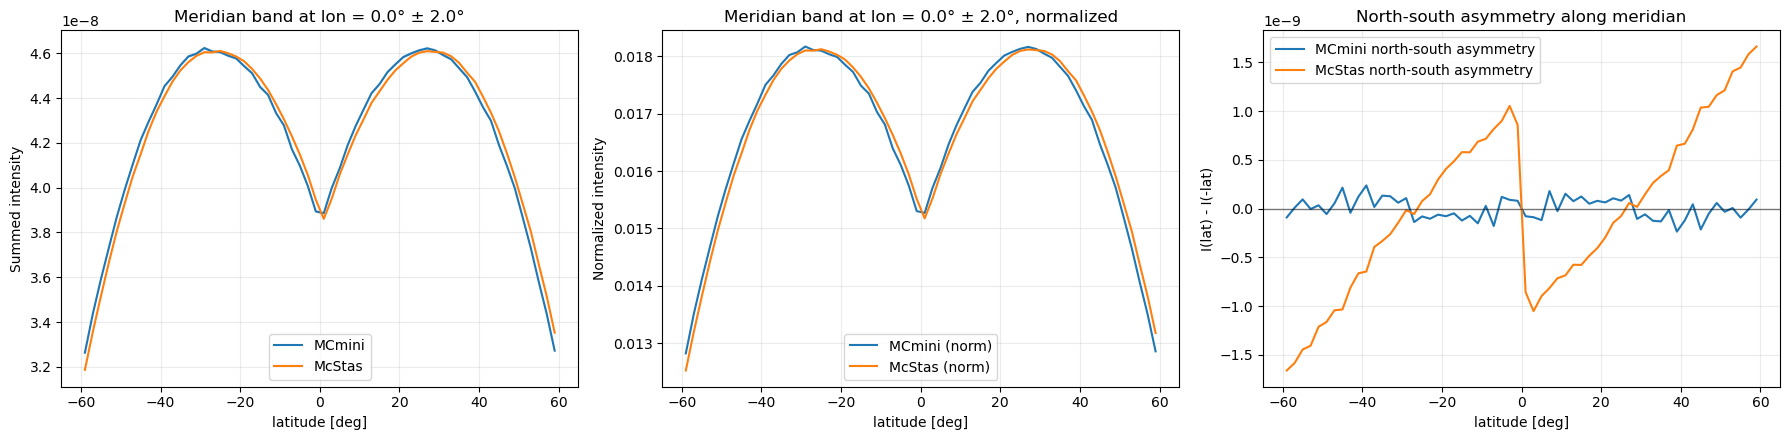

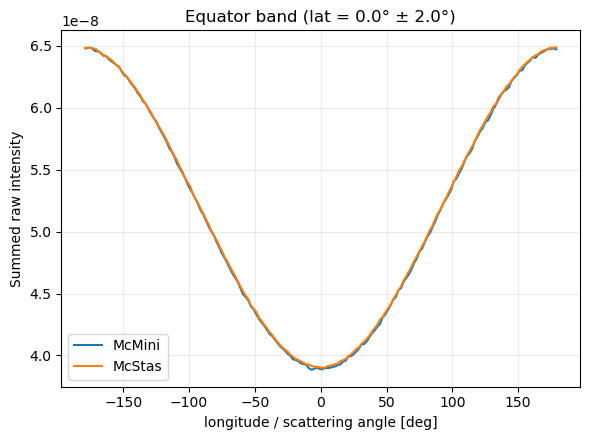

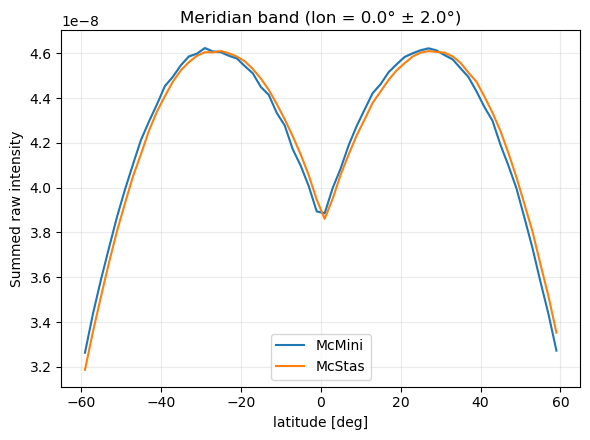

/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_14020/4056369849.py:483: RuntimeWarning: Mean of empty slice
  mini_mer_band_raw = np.nanmean(H_mini_raw[:, band_mask], axis=1)
/var/folders/td/xwsb6qn97jd2tvq057wsy3300000gn/T/ipykernel_14020/4056369849.py:484: RuntimeWarning: Mean of empty slice
  mcstas_mer_band_raw = np.nanmean(Hmc_raw[:, band_mask], axis=1)


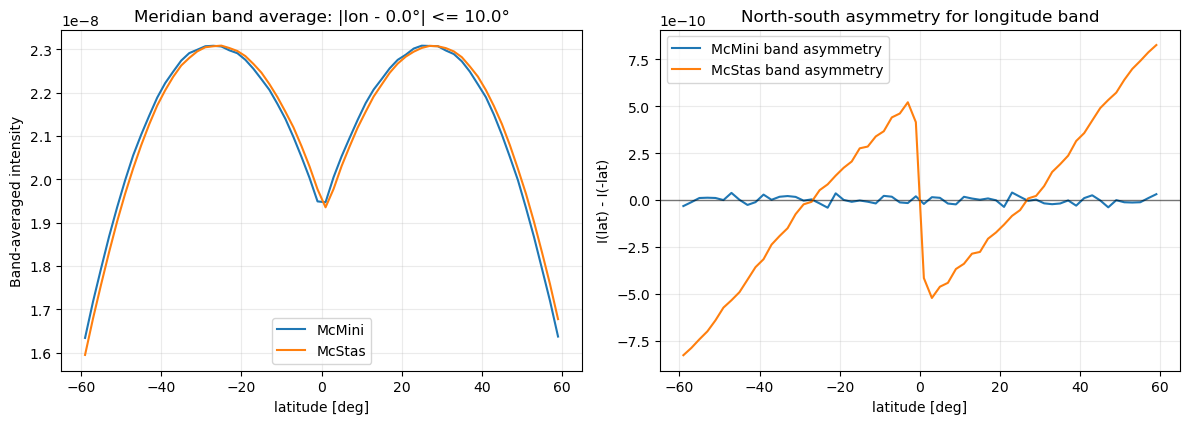

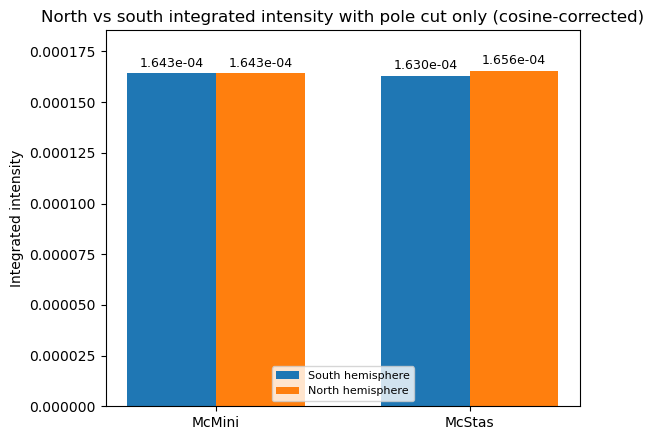

McMini north integrated intensity with pole cut only (raw):               1.340750e-04
McMini south integrated intensity with pole cut only (raw):               1.340717e-04
McMini raw hemisphere asymmetry (N-S)/(N+S):        1.225193e-05
McStas north integrated intensity with pole cut only (raw):               1.348485e-04
McStas south integrated intensity with pole cut only (raw):               1.332515e-04
McStas raw hemisphere asymmetry (N-S)/(N+S):        5.956652e-03
McMini north integrated intensity with pole cut only (corrected):         1.643133e-04
McMini south integrated intensity with pole cut only (corrected):         1.643111e-04
McMini hemisphere asymmetry (N-S)/(N+S):  6.719862e-06
McStas north integrated intensity with pole cut only (corrected):         1.655590e-04
McStas south integrated intensity with pole cut only (corrected):         1.630014e-04
McStas hemisphere asymmetry (N-S)/(N+S):  7.784356e-03
Total integrated intensity for McStas full corrected map (with p

In [72]:
pole_cut_deg = 30.0

def read_mcmini_n_history(path):
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.startswith("# n_history="):
                return int(line.split("=", 1)[1].strip())
    raise ValueError(f"Could not find n_history header in {path}")

def read_mcstas_ncount(sim_path):
    with open(sim_path, "r", encoding="utf-8") as f:
        for line in f:
            stripped = line.strip()
            if stripped.startswith("Ncount:"):
                return int(stripped.split(":", 1)[1].strip())
    raise ValueError(f"Could not find Ncount in {sim_path}")

def format_neutron_count(n):
    exponent = int(np.log10(n)) if n > 0 else 0
    if n == 10**exponent:
        return f"1e{exponent}"
    return f"{n:.3g}"

def read_mcmini_grid_shape(path):
    nx = ny = None
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.startswith("#"):
                break
            for item in line[1:].strip().split():
                if item.startswith("nx="):
                    nx = int(item.split("=", 1)[1])
                elif item.startswith("ny="):
                    ny = int(item.split("=", 1)[1])
    if nx is None or ny is None:
        raise ValueError(f"Could not find nx/ny header in {path}")
    return nx, ny

# mcmini data
# mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_sphere_validation/sphere_1cm_direconly_mcmini/sphere_1cm_multiple_scatter_3.csv")
mcmini_binned_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_cylinder_validation/HS_solcyl_r10mmh10mm_1e11_mcmini/HS_solcyl_r10mmh10mm_all_scatter.csv")
mcmini_n_history = read_mcmini_n_history(mcmini_binned_path)
mcmini_n_label = format_neutron_count(mcmini_n_history)

nx, ny = read_mcmini_grid_shape(mcmini_binned_path)
lon_edges = np.linspace(-180.0, 180.0, nx + 1)
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
lat_edges = np.linspace(-90.0, 90.0, ny + 1)
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])
cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
kept_lat_edges = lat_edges[np.r_[pole_mask, False] | np.r_[False, pole_mask]]
map_extent = [lon_edges[0], lon_edges[-1], kept_lat_edges[0], kept_lat_edges[-1]]
print(f"Pole cut: excluding |latitude| > {90.0 - pole_cut_deg:.1f} deg (last {pole_cut_deg:.1f} deg near each pole)")

binned_data = np.loadtxt(mcmini_binned_path, delimiter=',', comments='#')
col_counts = binned_data[:, 2]
H_mini = col_counts.reshape((ny, nx))  # (latitude bins, longitude bins)
if binned_data.shape[1] >= 4:
    sigma_mini = binned_data[:, 3].reshape((ny, nx))
else:
    sigma_mini = np.sqrt(np.maximum(H_mini * mcmini_n_history, 0.0)) / mcmini_n_history
H_mini_raw_all = H_mini
sigma_mini_raw_all = sigma_mini
H_mini_raw = H_mini
sigma_mini_raw = sigma_mini
H_mini_corr_all = H_mini / np.where(cos_correction == 0, np.nan, cos_correction)
sigma_mini_corr_all = sigma_mini / np.where(cos_correction == 0, np.nan, cos_correction)
H_mini_corr = H_mini_corr_all
sigma_mini_corr = sigma_mini_corr_all
H_mini_corr = np.where(pole_mask[:, np.newaxis], H_mini_corr, np.nan)
H_mini_raw = np.where(pole_mask[:, np.newaxis], H_mini_raw, np.nan)
sigma_mini_raw = np.where(pole_mask[:, np.newaxis], sigma_mini_raw, np.nan)
sigma_mini_corr = np.where(pole_mask[:, np.newaxis], sigma_mini_corr, np.nan)

# mcstas data 
mcstas_path = Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_cylinder_validation/HS_solcyl_r10mmh10mm_1e11_mcstas")
mcstas_ncount = read_mcstas_ncount(mcstas_path / "mccode.sim")
mcstas_n_label = format_neutron_count(mcstas_ncount)
sphere_mon = ms.load_data(str(mcstas_path))[0]  # adjust index if needed
meta = sphere_mon.metadata
hits = sphere_mon.Intensity
hits_err = sphere_mon.Error
xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]
Hmc = hits
Hmc_err = hits_err
if Hmc.shape == (meta.dimension[0], meta.dimension[1]):
    Hmc = Hmc.T
    Hmc_err = Hmc_err.T
if Hmc.shape != H_mini.shape:
    raise ValueError(f"McStas shape {Hmc.shape} does not match McMini shape {H_mini.shape}")
Hmc_raw_all = Hmc
sigma_mcstas_raw_all = Hmc_err
Hmc_raw = Hmc
sigma_mcstas_raw = Hmc_err
Hmc_corr_all = Hmc / np.where(cos_correction == 0, np.nan, cos_correction)  # apply same correction to McStas data
sigma_mcstas_corr_all = Hmc_err / np.where(cos_correction == 0, np.nan, cos_correction)
Hmc_corr = Hmc_corr_all
sigma_mcstas_corr = sigma_mcstas_corr_all
Hmc_corr = np.where(pole_mask[:, np.newaxis], Hmc_corr, np.nan)
Hmc_raw = np.where(pole_mask[:, np.newaxis], Hmc_raw, np.nan)
sigma_mcstas_raw = np.where(pole_mask[:, np.newaxis], sigma_mcstas_raw, np.nan)
sigma_mcstas_corr = np.where(pole_mask[:, np.newaxis], sigma_mcstas_corr, np.nan)
H_mini_raw_plot = H_mini_raw[pole_mask, :]
Hmc_raw_plot = Hmc_raw[pole_mask, :]
H_mini_corr_plot = H_mini_corr[pole_mask, :]
Hmc_corr_plot = Hmc_corr[pole_mask, :]

# plot raw side by side without difference map
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
extent = map_extent
vmin = min(np.nanmin(H_mini_raw_plot), np.nanmin(Hmc_raw_plot))
vmax = max(np.nanmax(H_mini_raw_plot), np.nanmax(Hmc_raw_plot))
axs[0].imshow(H_mini_raw_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title(f"Raw intensity (McMini, n={mcmini_n_label})")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Intensity")
axs[1].imshow(Hmc_raw_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
axs[1].set_xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
axs[1].set_ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
axs[1].set_title(f"Raw intensity (McStas, n={mcstas_n_label})")
fig.colorbar(axs[1].images[0], ax=axs[1], label="Intensity")
plt.tight_layout()
plt.show()
#p rint integrated intensity in each raw map   
print(f"Total raw intensity (mcmini, n={mcmini_n_label}) = {np.nansum(H_mini_raw):.6e}")
print(f"Total raw intensity (McStas, n={mcstas_n_label}) = {np.nansum(Hmc_raw):.6e}")
print(f"Ratio of total raw intensities (mini/mcstas) = {np.nansum(H_mini_raw) / np.nansum(Hmc_raw):.10e}")

#print integrated intensity in each map
print(f"Total cosine corrected intensity (mcmini, n={mcmini_n_label}) = {np.nansum(H_mini_corr):.6e}")
print(f"Total cosine corrected intensity (McStas, n={mcstas_n_label}) = {np.nansum(Hmc_corr):.6e}")
print(f"Ratio of total cosine corrected intensities (mini/mcstas) = {np.nansum(H_mini_corr) / np.nansum(Hmc_corr):.6e}")

# plot comparison maps separately for LaTeX subfigures
diff_corr = H_mini_corr - Hmc_corr
extent = map_extent
diff_corr_plot = diff_corr[pole_mask, :]
vmin = min(np.nanmin(H_mini_corr_plot), np.nanmin(Hmc_corr_plot))
vmax = max(np.nanmax(H_mini_corr_plot), np.nanmax(Hmc_corr_plot))
diff_absmax = np.nanmax(np.abs(diff_corr_plot))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(H_mini_corr_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.set_title(f"Cosine corrected intensity (McMini, n={mcmini_n_label})")
fig.colorbar(im, ax=ax, label="Intensity / cos(latitude)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(Hmc_corr_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
ax.set_xlabel(meta.xlabel if hasattr(meta, "xlabel") else "phi [deg]")
ax.set_ylabel(meta.ylabel if hasattr(meta, "ylabel") else "theta [deg]")
ax.set_title(f"Cosine corrected intensity (McStas, n={mcstas_n_label})")
fig.colorbar(im, ax=ax, label="Intensity / cos(latitude)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(diff_corr_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-diff_absmax, vmax=diff_absmax)
ax.set_xlabel("longitude [deg]")
ax.set_ylabel("latitude [deg]")
ax.set_title("Difference map (MCmini - McStas)")
fig.colorbar(im, ax=ax, label="Delta intensity / cos(latitude)")
plt.tight_layout()
plt.show()

diff_corr_all = H_mini_corr_all - Hmc_corr_all
sigma_combined_all = np.sqrt(sigma_mini_corr_all**2 + sigma_mcstas_corr_all**2)
pull_all = diff_corr_all / np.maximum(sigma_combined_all, 1e-30)
valid_all = np.isfinite(diff_corr_all) & np.isfinite(pull_all)
n_valid_all = np.sum(valid_all)
chi2_corr_all = np.nansum(pull_all[valid_all]**2)
chi2_red_corr_all = chi2_corr_all / n_valid_all if n_valid_all > 0 else np.nan

sigma_combined_full = np.sqrt(sigma_mini_corr**2 + sigma_mcstas_corr**2)
pull_full = diff_corr / np.maximum(sigma_combined_full, 1e-30)
valid_full = np.isfinite(diff_corr) & np.isfinite(pull_full)
n_valid_full = np.sum(valid_full)
mean_residual_corr = np.nanmean(diff_corr)
mae_residual_corr = np.nanmean(np.abs(diff_corr))
rms_residual_corr = np.sqrt(np.nanmean(diff_corr**2))
mean_pull_corr = np.nanmean(pull_full)
std_pull_corr = np.nanstd(pull_full)
chi2_corr = np.nansum(pull_full[valid_full]**2)
chi2_red_corr = chi2_corr / n_valid_full if n_valid_full > 0 else np.nan

print(f"Mean residual for cosine-corrected difference map: {mean_residual_corr:.6e}")
print(f"Mean absolute residual (cosine-corrected):         {mae_residual_corr:.6e}")
print(f"RMS residual (cosine-corrected):                   {rms_residual_corr:.6e}")
print(f"Mean pull (cosine-corrected):                      {mean_pull_corr:.6e}")
print(f"Pull std (cosine-corrected):                       {std_pull_corr:.6e}")
print(f"Reduced chi^2 (cosine-corrected, before pole cut; N={n_valid_all} bins): {chi2_red_corr_all:.6e}")
print(f"Reduced chi^2 (cosine-corrected, after {pole_cut_deg:.1f} deg pole cut; N={n_valid_full} bins): {chi2_red_corr:.6e}")

# extra diagnostics for systematic structure over all non-pole bins
sigma_combined_map = np.sqrt(sigma_mini_corr**2 + sigma_mcstas_corr**2)
significance_map = diff_corr / np.maximum(sigma_combined_map, 1e-30)
exclusion_mask = np.zeros_like(diff_corr, dtype=bool)
diff_corr_masked = diff_corr
significance_map_masked = significance_map
diff_corr_masked_plot = diff_corr_masked[pole_mask, :]
significance_map_masked_plot = significance_map_masked[pole_mask, :]
lat_residual_mean = np.nanmean(diff_corr_masked, axis=1)
lat_counts = np.sum(np.isfinite(diff_corr_masked), axis=1)
lat_residual_sem = np.nanstd(diff_corr_masked, axis=1) / np.sqrt(np.maximum(lat_counts, 1))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
raw_diff_absmax = np.nanmax(np.abs(diff_corr_masked_plot))
sig_absmax = min(np.nanmax(np.abs(significance_map_masked_plot)), 8.0)
axs[0].imshow(diff_corr_masked_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-raw_diff_absmax, vmax=raw_diff_absmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title("Residual map")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Delta intensity / cos(latitude)")
axs[1].imshow(significance_map_masked_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-sig_absmax, vmax=sig_absmax)
axs[1].set_xlabel("longitude [deg]")
axs[1].set_ylabel("latitude [deg]")
axs[1].set_title("Residual significance map")
fig.colorbar(axs[1].images[0], ax=axs[1], label="(MCmini - McStas) / sigma_combined")
axs[2].plot(lat_centers, lat_residual_mean, lw=1.5)
axs[2].fill_between(lat_centers, lat_residual_mean - lat_residual_sem, lat_residual_mean + lat_residual_sem, alpha=0.25)
axs[2].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[2].set_xlabel("latitude [deg]")
axs[2].set_ylabel("Mean residual")
axs[2].set_title("Latitude-averaged residual")
axs[2].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Residual RMS: {np.sqrt(np.nanmean(diff_corr_masked**2)):.6e}")
print(f"Mean |significance|: {np.nanmean(np.abs(significance_map_masked)):.6f}")

# same diagnostic without cosine correction
diff_raw_all = H_mini_raw_all - Hmc_raw_all
sigma_combined_raw_all = np.sqrt(sigma_mini_raw_all**2 + sigma_mcstas_raw_all**2)
pull_raw_all = diff_raw_all / np.maximum(sigma_combined_raw_all, 1e-30)
valid_raw_all = np.isfinite(diff_raw_all) & np.isfinite(pull_raw_all)
n_valid_raw_all = np.sum(valid_raw_all)
chi2_raw_all = np.nansum(pull_raw_all[valid_raw_all]**2)
chi2_red_raw_all = chi2_raw_all / n_valid_raw_all if n_valid_raw_all > 0 else np.nan

diff_raw = H_mini_raw - Hmc_raw
sigma_combined_raw = np.sqrt(sigma_mini_raw**2 + sigma_mcstas_raw**2)
significance_raw = diff_raw / np.maximum(sigma_combined_raw, 1e-30)
valid_raw = np.isfinite(diff_raw) & np.isfinite(significance_raw)
n_valid_raw = np.sum(valid_raw)
chi2_raw = np.nansum(significance_raw[valid_raw]**2)
chi2_red_raw = chi2_raw / n_valid_raw if n_valid_raw > 0 else np.nan
diff_raw_masked = diff_raw
significance_raw_masked = significance_raw
diff_raw_masked_plot = diff_raw_masked[pole_mask, :]
significance_raw_masked_plot = significance_raw_masked[pole_mask, :]
lat_residual_mean_raw = np.nanmean(diff_raw_masked, axis=1)
lat_counts_raw = np.sum(np.isfinite(diff_raw_masked), axis=1)
lat_residual_sem_raw = np.nanstd(diff_raw_masked, axis=1) / np.sqrt(np.maximum(lat_counts_raw, 1))

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
raw_diff_absmax = np.nanmax(np.abs(diff_raw_masked_plot))
raw_sig_absmax = min(np.nanmax(np.abs(significance_raw_masked_plot)), 8.0)
axs[0].imshow(diff_raw_masked_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-raw_diff_absmax, vmax=raw_diff_absmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title("Residual map without cosine correction")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Delta intensity")
axs[1].imshow(significance_raw_masked_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-raw_sig_absmax, vmax=raw_sig_absmax)
axs[1].set_xlabel("longitude [deg]")
axs[1].set_ylabel("latitude [deg]")
axs[1].set_title("Residual significance without cosine correction")
fig.colorbar(axs[1].images[0], ax=axs[1], label="(MCmini - McStas) / sigma_combined")
axs[2].plot(lat_centers, lat_residual_mean_raw, lw=1.5)
axs[2].fill_between(lat_centers, lat_residual_mean_raw - lat_residual_sem_raw, lat_residual_mean_raw + lat_residual_sem_raw, alpha=0.25)
axs[2].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[2].set_xlabel("latitude [deg]")
axs[2].set_ylabel("Mean residual")
axs[2].set_title("Latitude-averaged residual without cosine correction")
axs[2].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Raw residual RMS: {np.sqrt(np.nanmean(diff_raw_masked**2)):.6e}")
print(f"Raw mean |significance|: {np.nanmean(np.abs(significance_raw_masked)):.6f}")
print(f"Reduced chi^2 (raw, before pole cut; N={n_valid_raw_all} bins): {chi2_red_raw_all:.6e}")
print(f"Reduced chi^2 (raw, after {pole_cut_deg:.1f} deg pole cut; N={n_valid_raw} bins): {chi2_red_raw:.6e}")

# alignment tests: flips and 1-bin shifts applied to the McStas map
def score_alignment(reference, candidate, mask):
    diff = np.where(mask, np.nan, reference - candidate)
    return np.sqrt(np.nanmean(diff**2))

alignment_candidates = {
    "none": Hmc_raw,
    "lat_flip": Hmc_raw[::-1, :],
    "lon_flip": Hmc_raw[:, ::-1],
    "lat_shift_+1": np.roll(Hmc_raw, 1, axis=0),
    "lat_shift_-1": np.roll(Hmc_raw, -1, axis=0),
    "lon_shift_+1": np.roll(Hmc_raw, 1, axis=1),
    "lon_shift_-1": np.roll(Hmc_raw, -1, axis=1),
}
alignment_scores = {name: score_alignment(H_mini_raw, candidate, exclusion_mask) for name, candidate in alignment_candidates.items()}
best_alignment = min(alignment_scores, key=alignment_scores.get)
print("Alignment scan on raw maps (lower RMS is better):")
for name in sorted(alignment_scores, key=alignment_scores.get):
    print(f"  {name:12s} {alignment_scores[name]:.6e}")
print(f"Best candidate: {best_alignment} (RMS={alignment_scores[best_alignment]:.6e})")

best_candidate = alignment_candidates[best_alignment]
best_diff = H_mini_raw - best_candidate
best_diff_plot = best_diff[pole_mask, :]
best_diff_absmax = np.nanmax(np.abs(best_diff_plot))
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].imshow(diff_raw_masked_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-best_diff_absmax, vmax=best_diff_absmax)
axs[0].set_xlabel("longitude [deg]")
axs[0].set_ylabel("latitude [deg]")
axs[0].set_title("Original raw residual")
fig.colorbar(axs[0].images[0], ax=axs[0], label="Delta intensity")
axs[1].imshow(best_diff_plot, origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-best_diff_absmax, vmax=best_diff_absmax)
axs[1].set_xlabel("longitude [deg]")
axs[1].set_ylabel("latitude [deg]")
axs[1].set_title(f"Residual after {best_alignment}")
fig.colorbar(axs[1].images[0], ax=axs[1], label="Delta intensity")
plt.tight_layout()
plt.show()

#print sum of intensities
print(f"Total intensity (mcmini, n={mcmini_n_label}) =", H_mini.sum())
print(f"Total intensity (McStas, n={mcstas_n_label}) =", Hmc.sum())
ratio = H_mini.sum() / Hmc.sum()
print("Ratio of total intensities (mini/mcstas) =", ratio)


# --- 1D cut langs ækvator (latitude = 0 deg) ---

# Latitude-bin-centre for ny=180 over [-90, 90]
lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

# Use a 2-degree band centered on 0 deg: bin centers -0.5 and +0.5 deg
equator_band_halfwidth_deg = 2.0
eq_band_mask = np.abs(lat_centers) <= equator_band_halfwidth_deg
eq_lat = 0.0
eq_band_centers = lat_centers[eq_band_mask]
print(f"Using equator band centered at {eq_lat:.1f} deg with bin centers: {eq_band_centers}")

# Longitude-akse (spredningsvinkel i dit plot-setup)
lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])

# 1D profiles summed over the equator band, without cosine correction.
# For a sum of independent bins, sigma_sum = sqrt(sum(sigma_i^2)).
mini_eq = np.nansum(H_mini_raw[eq_band_mask, :], axis=0)
mcstas_eq = np.nansum(Hmc_raw[eq_band_mask, :], axis=0)
mini_eq_count = np.sum(np.isfinite(H_mini_raw[eq_band_mask, :]) & np.isfinite(sigma_mini_raw[eq_band_mask, :]), axis=0)
mcstas_eq_count = np.sum(np.isfinite(Hmc_raw[eq_band_mask, :]) & np.isfinite(sigma_mcstas_raw[eq_band_mask, :]), axis=0)
mini_eq_sigma = np.sqrt(np.nansum(sigma_mini_raw[eq_band_mask, :]**2, axis=0))
mcstas_eq_sigma = np.sqrt(np.nansum(sigma_mcstas_raw[eq_band_mask, :]**2, axis=0))
mini_eq_sigma = np.where(mini_eq_count > 0, mini_eq_sigma, np.nan)
mcstas_eq_sigma = np.where(mcstas_eq_count > 0, mcstas_eq_sigma, np.nan)

# Normaliseret 1D (form-sammenligning)
mini_eq_norm = mini_eq / np.nansum(mini_eq)
mcstas_eq_norm = mcstas_eq / np.nansum(mcstas_eq)

# Absolut + normaliseret plot
fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))

# Absolut 1D cut
axs[0].plot(lon_centers, mini_eq, label="MCmini", lw=1.5)
axs[0].fill_between(lon_centers, mini_eq - mini_eq_sigma, mini_eq + mini_eq_sigma, alpha=0.2)
axs[0].plot(lon_centers, mcstas_eq, label="McStas", lw=1.5)
axs[0].fill_between(lon_centers, mcstas_eq - mcstas_eq_sigma, mcstas_eq + mcstas_eq_sigma, alpha=0.2)
axs[0].set_xlabel("longitude / scattering angle [deg]")
axs[0].set_ylabel("Summed raw intensity")
axs[0].set_title(f"1D equator band (lat = {eq_lat:.1f}° ± {equator_band_halfwidth_deg:.1f}°), raw")
axs[0].legend()
axs[0].grid(alpha=0.25)

# Normaliseret 1D cut (kun form)
axs[1].plot(lon_centers, mini_eq_norm, label="MCmini (norm)", lw=1.5)
axs[1].plot(lon_centers, mcstas_eq_norm, label="McStas (norm)", lw=1.5)
axs[1].set_xlabel("longitude / scattering angle [deg]")
axs[1].set_ylabel("Normalized intensity")
axs[1].set_title(f"1D equator band (lat = {eq_lat:.1f}° ± {equator_band_halfwidth_deg:.1f}°), normalized")
axs[1].legend()
axs[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# --- 1D cut from south to north pole along a fixed longitude ---
meridian_lon_deg = 0.0
meridian_band_halfwidth_deg_for_cut = 2.0
mer_band_mask = np.abs(lon_centers - meridian_lon_deg) <= meridian_band_halfwidth_deg_for_cut
mer_lon = meridian_lon_deg
mer_band_centers = lon_centers[mer_band_mask]
print(f"Using meridian band centered at {mer_lon:.1f} deg with bin centers: {mer_band_centers}")

mini_mer_count = np.sum(np.isfinite(H_mini_raw[:, mer_band_mask]) & np.isfinite(sigma_mini_raw[:, mer_band_mask]), axis=1)
mcstas_mer_count = np.sum(np.isfinite(Hmc_raw[:, mer_band_mask]) & np.isfinite(sigma_mcstas_raw[:, mer_band_mask]), axis=1)
mini_mer_raw = np.where(mini_mer_count > 0, np.nansum(H_mini_raw[:, mer_band_mask], axis=1), np.nan)
mcstas_mer_raw = np.where(mcstas_mer_count > 0, np.nansum(Hmc_raw[:, mer_band_mask], axis=1), np.nan)
mini_mer_sigma_raw = np.sqrt(np.nansum(sigma_mini_raw[:, mer_band_mask]**2, axis=1))
mcstas_mer_sigma_raw = np.sqrt(np.nansum(sigma_mcstas_raw[:, mer_band_mask]**2, axis=1))
mini_mer_sigma_raw = np.where(mini_mer_count > 0, mini_mer_sigma_raw, np.nan)
mcstas_mer_sigma_raw = np.where(mcstas_mer_count > 0, mcstas_mer_sigma_raw, np.nan)

lat_centers_mer_cut = lat_centers[pole_mask]
mini_mer_raw_cut = mini_mer_raw[pole_mask]
mcstas_mer_raw_cut = mcstas_mer_raw[pole_mask]
mini_mer_sigma_raw_cut = mini_mer_sigma_raw[pole_mask]
mcstas_mer_sigma_raw_cut = mcstas_mer_sigma_raw[pole_mask]

mini_mer_norm = mini_mer_raw_cut / np.nansum(mini_mer_raw_cut)
mcstas_mer_norm = mcstas_mer_raw_cut / np.nansum(mcstas_mer_raw_cut)

# North-south asymmetry along the chosen meridian
mini_mer_asym = mini_mer_raw_cut - mini_mer_raw_cut[::-1]
mcstas_mer_asym = mcstas_mer_raw_cut - mcstas_mer_raw_cut[::-1]

fig, axs = plt.subplots(1, 3, figsize=(18, 4.5))
axs[0].plot(lat_centers_mer_cut, mini_mer_raw_cut, label="MCmini", lw=1.5)
axs[0].fill_between(lat_centers_mer_cut, mini_mer_raw_cut - mini_mer_sigma_raw_cut, mini_mer_raw_cut + mini_mer_sigma_raw_cut, alpha=0.2)
axs[0].plot(lat_centers_mer_cut, mcstas_mer_raw_cut, label="McStas", lw=1.5)
axs[0].fill_between(lat_centers_mer_cut, mcstas_mer_raw_cut - mcstas_mer_sigma_raw_cut, mcstas_mer_raw_cut + mcstas_mer_sigma_raw_cut, alpha=0.2)
axs[0].set_xlabel("latitude [deg]")
axs[0].set_ylabel("Summed intensity")
axs[0].set_title(f"Meridian band at lon = {mer_lon:.1f}° ± {meridian_band_halfwidth_deg_for_cut:.1f}°")
axs[0].legend()
axs[0].grid(alpha=0.25)

axs[1].plot(lat_centers_mer_cut, mini_mer_norm, label="MCmini (norm)", lw=1.5)
axs[1].plot(lat_centers_mer_cut, mcstas_mer_norm, label="McStas (norm)", lw=1.5)
axs[1].set_xlabel("latitude [deg]")
axs[1].set_ylabel("Normalized intensity")
axs[1].set_title(f"Meridian band at lon = {mer_lon:.1f}° ± {meridian_band_halfwidth_deg_for_cut:.1f}°, normalized")
axs[1].legend()
axs[1].grid(alpha=0.25)

axs[2].plot(lat_centers_mer_cut, mini_mer_asym, label="MCmini north-south asymmetry", lw=1.5)
axs[2].plot(lat_centers_mer_cut, mcstas_mer_asym, label="McStas north-south asymmetry", lw=1.5)
axs[2].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[2].set_xlabel("latitude [deg]")
axs[2].set_ylabel("I(lat) - I(-lat)")
axs[2].set_title("North-south asymmetry along meridian")
axs[2].legend()
axs[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Separate absolute cuts for LaTeX subfigures
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(lon_centers, mini_eq, label="McMini", lw=1.5)
ax.fill_between(lon_centers, mini_eq - mini_eq_sigma, mini_eq + mini_eq_sigma, alpha=0.2)
ax.plot(lon_centers, mcstas_eq, label="McStas", lw=1.5)
ax.fill_between(lon_centers, mcstas_eq - mcstas_eq_sigma, mcstas_eq + mcstas_eq_sigma, alpha=0.2)
ax.set_xlabel("longitude / scattering angle [deg]")
ax.set_ylabel("Summed raw intensity")
ax.set_title(f"Equator band (lat = {eq_lat:.1f}° ± {equator_band_halfwidth_deg:.1f}°)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(lat_centers_mer_cut, mini_mer_raw_cut, label="McMini", lw=1.5)
ax.fill_between(lat_centers_mer_cut, mini_mer_raw_cut - mini_mer_sigma_raw_cut, mini_mer_raw_cut + mini_mer_sigma_raw_cut, alpha=0.2)
ax.plot(lat_centers_mer_cut, mcstas_mer_raw_cut, label="McStas", lw=1.5)
ax.fill_between(lat_centers_mer_cut, mcstas_mer_raw_cut - mcstas_mer_sigma_raw_cut, mcstas_mer_raw_cut + mcstas_mer_sigma_raw_cut, alpha=0.2)
ax.set_xlabel("latitude [deg]")
ax.set_ylabel("Summed raw intensity")
ax.set_title(f"Meridian band (lon = {mer_lon:.1f}° ± {meridian_band_halfwidth_deg_for_cut:.1f}°)")
ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Band-averaged north-south asymmetry around the chosen meridian to reduce noise
meridian_band_halfwidth_deg = 10.0
band_mask = np.abs(lon_centers - mer_lon) <= meridian_band_halfwidth_deg
mini_mer_band_raw = np.nanmean(H_mini_raw[:, band_mask], axis=1)
mcstas_mer_band_raw = np.nanmean(Hmc_raw[:, band_mask], axis=1)
mini_mer_band_sigma = np.sqrt(np.nansum(sigma_mini_raw[:, band_mask]**2, axis=1)) / np.maximum(np.sum(np.isfinite(sigma_mini_raw[:, band_mask]), axis=1), 1)
mcstas_mer_band_sigma = np.sqrt(np.nansum(sigma_mcstas_raw[:, band_mask]**2, axis=1)) / np.maximum(np.sum(np.isfinite(sigma_mcstas_raw[:, band_mask]), axis=1), 1)
mini_mer_band_raw_cut = mini_mer_band_raw[pole_mask]
mcstas_mer_band_raw_cut = mcstas_mer_band_raw[pole_mask]
mini_mer_band_sigma_cut = mini_mer_band_sigma[pole_mask]
mcstas_mer_band_sigma_cut = mcstas_mer_band_sigma[pole_mask]
mini_mer_band_asym = mini_mer_band_raw_cut - mini_mer_band_raw_cut[::-1]
mcstas_mer_band_asym = mcstas_mer_band_raw_cut - mcstas_mer_band_raw_cut[::-1]

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].plot(lat_centers_mer_cut, mini_mer_band_raw_cut, label="McMini", lw=1.5)
axs[0].fill_between(lat_centers_mer_cut, mini_mer_band_raw_cut - mini_mer_band_sigma_cut, mini_mer_band_raw_cut + mini_mer_band_sigma_cut, alpha=0.2)
axs[0].plot(lat_centers_mer_cut, mcstas_mer_band_raw_cut, label="McStas", lw=1.5)
axs[0].fill_between(lat_centers_mer_cut, mcstas_mer_band_raw_cut - mcstas_mer_band_sigma_cut, mcstas_mer_band_raw_cut + mcstas_mer_band_sigma_cut, alpha=0.2)
axs[0].set_xlabel("latitude [deg]")
axs[0].set_ylabel("Band-averaged intensity")
axs[0].set_title(f"Meridian band average: |lon - {mer_lon:.1f}°| <= {meridian_band_halfwidth_deg:.1f}°")
axs[0].legend()
axs[0].grid(alpha=0.25)
axs[1].plot(lat_centers_mer_cut, mini_mer_band_asym, label="McMini band asymmetry", lw=1.5)
axs[1].plot(lat_centers_mer_cut, mcstas_mer_band_asym, label="McStas band asymmetry", lw=1.5)
axs[1].axhline(0.0, color="k", lw=1.0, alpha=0.5)
axs[1].set_xlabel("latitude [deg]")
axs[1].set_ylabel("I(lat) - I(-lat)")
axs[1].set_title("North-south asymmetry for longitude band")
axs[1].legend()
axs[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


# Hemisphere-integrated north-vs-south comparison with pole cut only.
# Use cosine-corrected maps so the integral is less sensitive to latitude-bin area.
# Keep the equatorial band and exclude only the last pole_cut_deg near each pole.
south_mask = lat_centers < 0
north_mask = lat_centers >= 0
mini_south_raw = np.nansum(H_mini_raw[south_mask, :])
mini_north_raw = np.nansum(H_mini_raw[north_mask, :])
mcstas_south_raw = np.nansum(Hmc_raw[south_mask, :])
mcstas_north_raw = np.nansum(Hmc_raw[north_mask, :])
mini_hemi_asym_raw = (mini_north_raw - mini_south_raw) / (mini_north_raw + mini_south_raw)
mcstas_hemi_asym_raw = (mcstas_north_raw - mcstas_south_raw) / (mcstas_north_raw + mcstas_south_raw)
mini_south = np.nansum(H_mini_corr[south_mask, :])
mini_north = np.nansum(H_mini_corr[north_mask, :])
mcstas_south = np.nansum(Hmc_corr[south_mask, :])
mcstas_north = np.nansum(Hmc_corr[north_mask, :])
mini_hemi_asym = (mini_north - mini_south) / (mini_north + mini_south)
mcstas_hemi_asym = (mcstas_north - mcstas_south) / (mcstas_north + mcstas_south)

fig, ax = plt.subplots(figsize=(6, 4.5))
labels = ["McMini", "McStas"]
north_vals = [mini_north, mcstas_north]
south_vals = [mini_south, mcstas_south]
x = np.arange(len(labels))
w = 0.35
south_bars = ax.bar(x - w/2, south_vals, width=w, label="South hemisphere")
north_bars = ax.bar(x + w/2, north_vals, width=w, label="North hemisphere")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Integrated intensity")
ax.set_title(f"North vs south integrated intensity with pole cut only (cosine-corrected)")
ax.legend(prop={'size': 8}, loc="lower center")
ymax_bar = max(max(south_vals), max(north_vals))
ax.set_ylim(0, ymax_bar * 1.12)
label_offset = ymax_bar * 0.01
for bars in (south_bars, north_bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + label_offset,
            f"{height:.3e}",
            ha="center",
            va="bottom",
            rotation=0,
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8),
        )
plt.tight_layout()
plt.show()

print(f"McMini north integrated intensity with pole cut only (raw):               {mini_north_raw:.6e}")
print(f"McMini south integrated intensity with pole cut only (raw):               {mini_south_raw:.6e}")
print(f"McMini raw hemisphere asymmetry (N-S)/(N+S):        {mini_hemi_asym_raw:.6e}")
print(f"McStas north integrated intensity with pole cut only (raw):               {mcstas_north_raw:.6e}")
print(f"McStas south integrated intensity with pole cut only (raw):               {mcstas_south_raw:.6e}")
print(f"McStas raw hemisphere asymmetry (N-S)/(N+S):        {mcstas_hemi_asym_raw:.6e}")
print(f"McMini north integrated intensity with pole cut only (corrected):         {mini_north:.6e}")
print(f"McMini south integrated intensity with pole cut only (corrected):         {mini_south:.6e}")
print(f"McMini hemisphere asymmetry (N-S)/(N+S):  {mini_hemi_asym:.6e}")
print(f"McStas north integrated intensity with pole cut only (corrected):         {mcstas_north:.6e}")
print(f"McStas south integrated intensity with pole cut only (corrected):         {mcstas_south:.6e}")
print(f"McStas hemisphere asymmetry (N-S)/(N+S):  {mcstas_hemi_asym:.6e}")

# Kvantitativ 1D sammenligning
valid = np.isfinite(mini_eq) & np.isfinite(mcstas_eq) & np.isfinite(mini_eq_sigma) & np.isfinite(mcstas_eq_sigma)
a = mini_eq[valid]
b = mcstas_eq[valid]
sigma_a = mini_eq_sigma[valid]
sigma_b = mcstas_eq_sigma[valid]

pearson_1d = np.corrcoef(a, b)[0, 1]
rmse_1d = np.sqrt(np.mean((a - b)**2))
mae_1d = np.mean(np.abs(a - b))
scale_1d = np.nansum(a) / np.nansum(b)

# Uncertainty-aware GOF on the absolute equator cut
sigma_combined = np.sqrt(sigma_a**2 + sigma_b**2)
chi2_1d = np.sum((a - b)**2 / np.maximum(sigma_combined**2, 1e-30))
ndof_1d = max(len(a), 1)
chi2_red_1d = chi2_1d / ndof_1d
mean_abs_pull = np.mean(np.abs((a - b) / np.maximum(sigma_combined, 1e-30)))

# Statistical shape tests on the normalized equator cut
eps = 1e-30
a_norm = a / np.sum(a)
b_norm = b / np.sum(b)
cdf_a = np.cumsum(a_norm)
cdf_b = np.cumsum(b_norm)
ks_like_1d = np.max(np.abs(cdf_a - cdf_b))
chi2_shape = np.sum((a_norm - b_norm)**2 / np.maximum(b_norm, eps))
chi2_shape_reduced = chi2_shape / max(len(a_norm) - 1, 1)
cosine_similarity_1d = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Same raw 1D statistics for the meridian band.
valid_mer = np.isfinite(mini_mer_raw_cut) & np.isfinite(mcstas_mer_raw_cut) & np.isfinite(mini_mer_sigma_raw_cut) & np.isfinite(mcstas_mer_sigma_raw_cut)
a_mer = mini_mer_raw_cut[valid_mer]
b_mer = mcstas_mer_raw_cut[valid_mer]
sigma_a_mer = mini_mer_sigma_raw_cut[valid_mer]
sigma_b_mer = mcstas_mer_sigma_raw_cut[valid_mer]
pearson_mer_1d = np.corrcoef(a_mer, b_mer)[0, 1]
scale_mer_1d = np.nansum(a_mer) / np.nansum(b_mer)
sigma_combined_mer = np.sqrt(sigma_a_mer**2 + sigma_b_mer**2)
chi2_mer_1d = np.sum((a_mer - b_mer)**2 / np.maximum(sigma_combined_mer**2, 1e-30))
ndof_mer_1d = max(len(a_mer), 1)
chi2_red_mer_1d = chi2_mer_1d / ndof_mer_1d

print(f"Total integrated intensity for McStas full corrected map (with poles cut): {np.nansum(Hmc_corr):.6e}")
print(f"Total integrated intensity for McMini full corrected map (with poles cut): {np.nansum(H_mini_corr):.6e}")
print(f"Intesity ratio of total integrated intensities (mini/mcstas) for full corrected maps: {np.nansum(H_mini_corr) / np.nansum(Hmc_corr):.6e}")
print(f"Northern hemisphere integrated intensity for McStas full corrected map (0° <= lat <= 85°): {np.nansum(Hmc_corr[lat_centers >= 0, :]):.6e}")
print(f"Northern hemisphere integrated intensity for McMini full corrected map (0° <= lat <= 85°): {np.nansum(H_mini_corr[lat_centers >= 0, :]):.6e}")
print(f"Southern hemisphere integrated intensity for McStas full corrected map (-85° <= lat < 0°): {np.nansum(Hmc_corr[lat_centers < 0, :]):.6e}")
print(f"Southern hemisphere integrated intensity for McMini full corrected map (-85° <= lat < 0°): {np.nansum(H_mini_corr[lat_centers < 0, :]):.6e}")
print("1D equator-cut statistics use raw intensity, not cosine-corrected intensity.")
print(f"Total integrated intensity for McStas raw equator-cut 1D profile: {np.nansum(b):.6e}")
print(f"Total integrated intensity for McMini raw equator-cut 1D profile: {np.nansum(a):.6e}")
print(f"1D Pearson r (raw absolute):        {pearson_1d:.6f}")
print(f"1D RMSE (raw absolute):             {rmse_1d:.6e}")
print(f"1D MAE (raw absolute):              {mae_1d:.6e}")
print(f"1D raw sum ratio mini/mcstas:       {scale_1d:.6f}")
print(f"1D chi^2 (raw absolute):            {chi2_1d:.6e}")
print(f"1D reduced chi^2 (raw):             {chi2_red_1d:.6e}")
print(f"1D raw mean |pull|:                 {mean_abs_pull:.6f}")
print(f"1D raw cosine similarity:           {cosine_similarity_1d:.6f}")
print(f"1D raw KS-like CDF distance:        {ks_like_1d:.6e}")
print(f"1D reduced chi^2 (raw shape only):  {chi2_shape_reduced:.6e}")
print(f"Raw meridian-cut Pearson correlation: {pearson_mer_1d:.6f}")
print(f"Raw meridian-cut sum ratio mini/mcstas: {scale_mer_1d:.6f}")
print(f"Raw meridian-cut reduced chi^2: {chi2_red_mer_1d:.6e}")
print("MCmini uncertainty uses the CSV sigma column; the current MCmini sphere monitor writes sigma = sqrt(sum(w^2)) after per-history normalization.")
print("The Poisson approximation sqrt(I * n_history) / n_history is only used if the CSV has no sigma column.")
print("Note: KS-like and chi^2 on normalized profiles compare shape only; they are descriptive statistics, not exact p-value tests.")













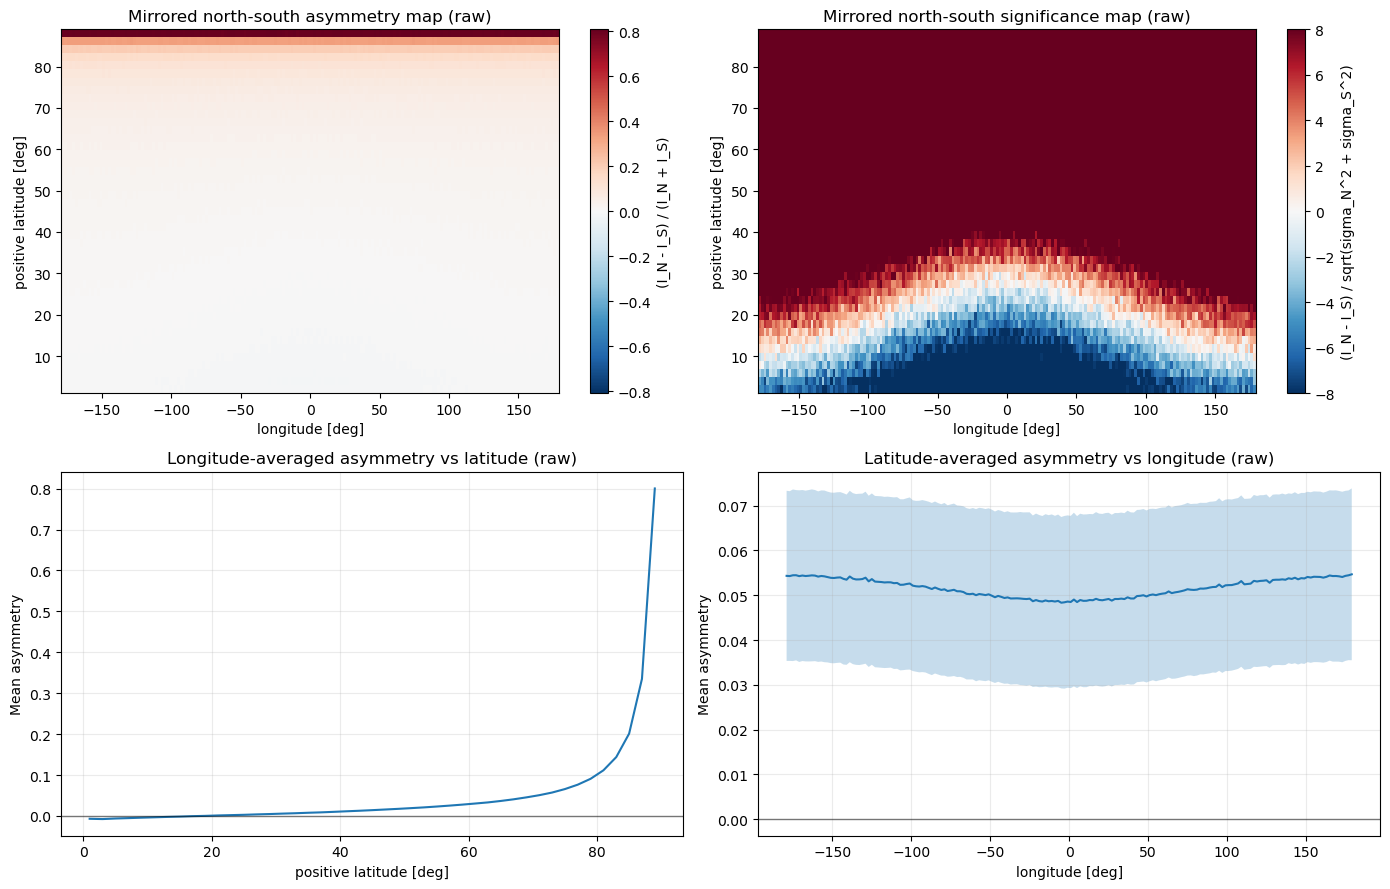

Raw mean mirrored asymmetry:      5.163669e-02
Raw std of mirrored asymmetry:    1.284805e-01
Raw mean |mirrored asymmetry|:    5.351724e-02


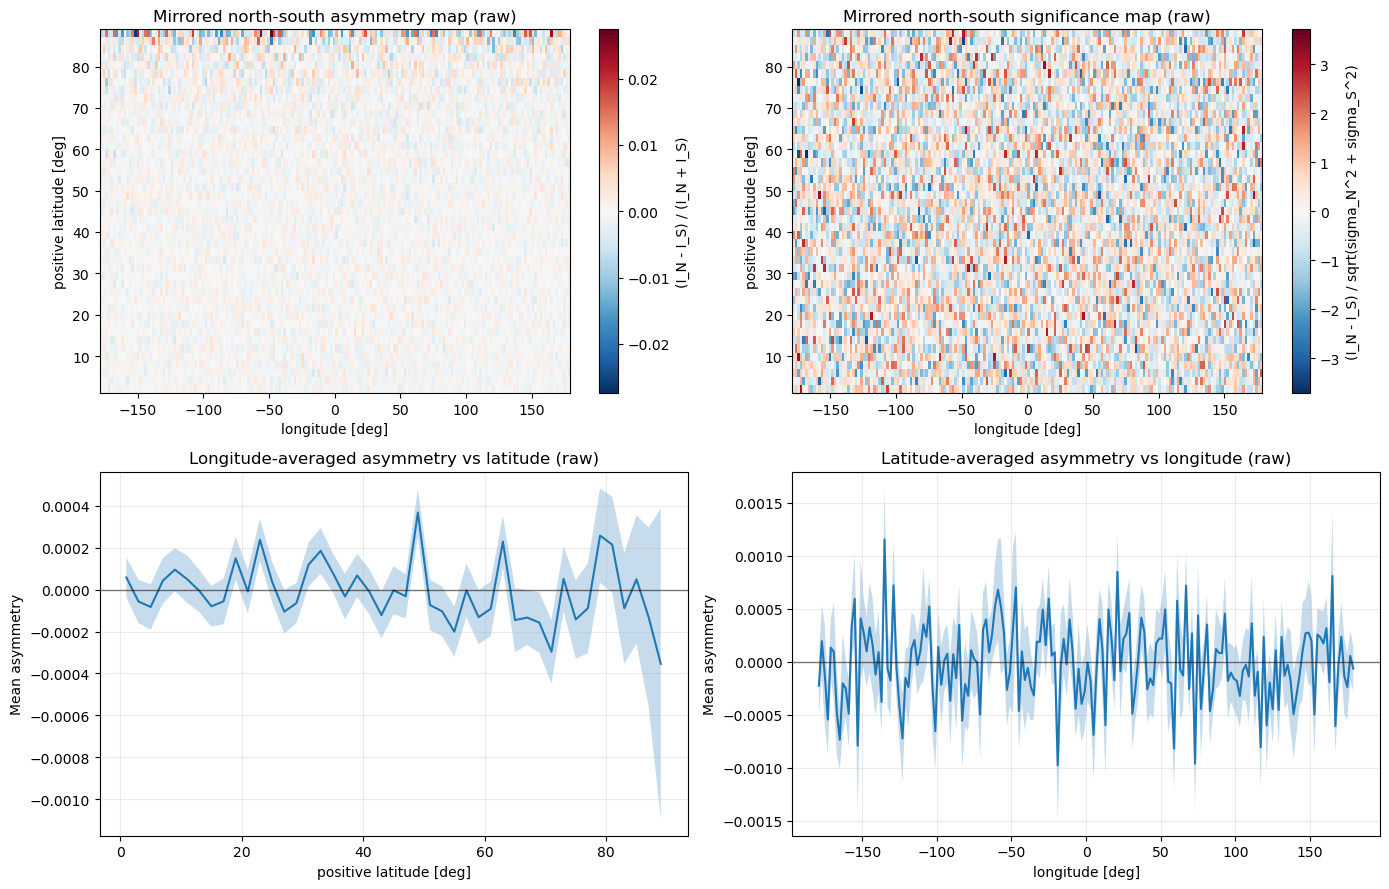

Raw mean mirrored asymmetry:      -1.170366e-05
Raw std of mirrored asymmetry:    2.506234e-03
Raw mean |mirrored asymmetry|:    1.626198e-03


In [67]:
# Mirrored north-south asymmetry diagnostics for the McStas 4PI data
# Assumes Hmc_raw, Hmc_corr, sigma_mcstas_raw, sigma_mcstas_corr, lat_centers, and lon_centers
# already exist from the main analysis cell.

def mirrored_asymmetry_diagnostics(I_map, sigma_map):
    lat_pos_mask = (lat_centers > 0.0) & pole_mask
    lat_pos = lat_centers[lat_pos_mask]

    north_I = I_map[lat_pos_mask, :]
    south_I = I_map[::-1, :][lat_pos_mask, :]
    north_sigma = sigma_map[lat_pos_mask, :]
    south_sigma = sigma_map[::-1, :][lat_pos_mask, :]

    sum_I = north_I + south_I
    diff_I = north_I - south_I
    denom_sigma = np.sqrt(north_sigma**2 + south_sigma**2)

    asym_map = diff_I / np.where(sum_I > 0, sum_I, np.nan)
    pull_map = diff_I / np.maximum(denom_sigma, 1e-30)

    asym_vs_lat = np.nanmean(asym_map, axis=1)
    asym_vs_lon = np.nanmean(asym_map, axis=0)
    asym_lat_sem = np.nanstd(asym_map, axis=1) / np.sqrt(np.maximum(np.sum(np.isfinite(asym_map), axis=1), 1))
    asym_lon_sem = np.nanstd(asym_map, axis=0) / np.sqrt(np.maximum(np.sum(np.isfinite(asym_map), axis=0), 1))

    stats = {
        "mean": float(np.nanmean(asym_map)),
        "std": float(np.nanstd(asym_map)),
        "mean_abs": float(np.nanmean(np.abs(asym_map))),
    }

    return {
        "lat_pos": lat_pos,
        "asym_map": asym_map,
        "pull_map": pull_map,
        "asym_vs_lat": asym_vs_lat,
        "asym_vs_lon": asym_vs_lon,
        "asym_lat_sem": asym_lat_sem,
        "asym_lon_sem": asym_lon_sem,
        "stats": stats,
    }


def plot_mirrored_asymmetry(result, label):
    lat_pos = result["lat_pos"]
    asym_map = result["asym_map"]
    pull_map = result["pull_map"]
    asym_vs_lat = result["asym_vs_lat"]
    asym_vs_lon = result["asym_vs_lon"]
    asym_lat_sem = result["asym_lat_sem"]
    asym_lon_sem = result["asym_lon_sem"]

    fig, axs = plt.subplots(2, 2, figsize=(14, 9))
    asym_absmax = np.nanmax(np.abs(asym_map))
    pull_absmax = min(np.nanmax(np.abs(pull_map)), 8.0)

    im0 = axs[0, 0].imshow(
        asym_map,
        origin="lower",
        extent=[lon_centers[0], lon_centers[-1], lat_pos[0], lat_pos[-1]],
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-asym_absmax,
        vmax=asym_absmax,
    )
    axs[0, 0].set_xlabel("longitude [deg]")
    axs[0, 0].set_ylabel("positive latitude [deg]")
    axs[0, 0].set_title(f"Mirrored north-south asymmetry map ({label})")
    fig.colorbar(im0, ax=axs[0, 0], label="(I_N - I_S) / (I_N + I_S)")

    im1 = axs[0, 1].imshow(
        pull_map,
        origin="lower",
        extent=[lon_centers[0], lon_centers[-1], lat_pos[0], lat_pos[-1]],
        aspect="auto",
        interpolation="nearest",
        cmap="RdBu_r",
        vmin=-pull_absmax,
        vmax=pull_absmax,
    )
    axs[0, 1].set_xlabel("longitude [deg]")
    axs[0, 1].set_ylabel("positive latitude [deg]")
    axs[0, 1].set_title(f"Mirrored north-south significance map ({label})")
    fig.colorbar(im1, ax=axs[0, 1], label="(I_N - I_S) / sqrt(sigma_N^2 + sigma_S^2)")

    axs[1, 0].plot(lat_pos, asym_vs_lat, lw=1.5)
    axs[1, 0].fill_between(lat_pos, asym_vs_lat - asym_lat_sem, asym_vs_lat + asym_lat_sem, alpha=0.25)
    axs[1, 0].axhline(0.0, color="k", lw=1.0, alpha=0.5)
    axs[1, 0].set_xlabel("positive latitude [deg]")
    axs[1, 0].set_ylabel("Mean asymmetry")
    axs[1, 0].set_title(f"Longitude-averaged asymmetry vs latitude ({label})")
    axs[1, 0].grid(alpha=0.25)

    axs[1, 1].plot(lon_centers, asym_vs_lon, lw=1.5)
    axs[1, 1].fill_between(lon_centers, asym_vs_lon - asym_lon_sem, asym_vs_lon + asym_lon_sem, alpha=0.25)
    axs[1, 1].axhline(0.0, color="k", lw=1.0, alpha=0.5)
    axs[1, 1].set_xlabel("longitude [deg]")
    axs[1, 1].set_ylabel("Mean asymmetry")
    axs[1, 1].set_title(f"Latitude-averaged asymmetry vs longitude ({label})")
    axs[1, 1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


raw_result = mirrored_asymmetry_diagnostics(Hmc_raw, sigma_mcstas_raw)
plot_mirrored_asymmetry(raw_result, "raw")
print(f"Raw mean mirrored asymmetry:      {raw_result['stats']['mean']:.6e}")
print(f"Raw std of mirrored asymmetry:    {raw_result['stats']['std']:.6e}")
print(f"Raw mean |mirrored asymmetry|:    {raw_result['stats']['mean_abs']:.6e}")


raw_result = mirrored_asymmetry_diagnostics(H_mini_raw, sigma_mini_raw)
plot_mirrored_asymmetry(raw_result, "raw")
print(f"Raw mean mirrored asymmetry:      {raw_result['stats']['mean']:.6e}")
print(f"Raw std of mirrored asymmetry:    {raw_result['stats']['std']:.6e}")
print(f"Raw mean |mirrored asymmetry|:    {raw_result['stats']['mean_abs']:.6e}")





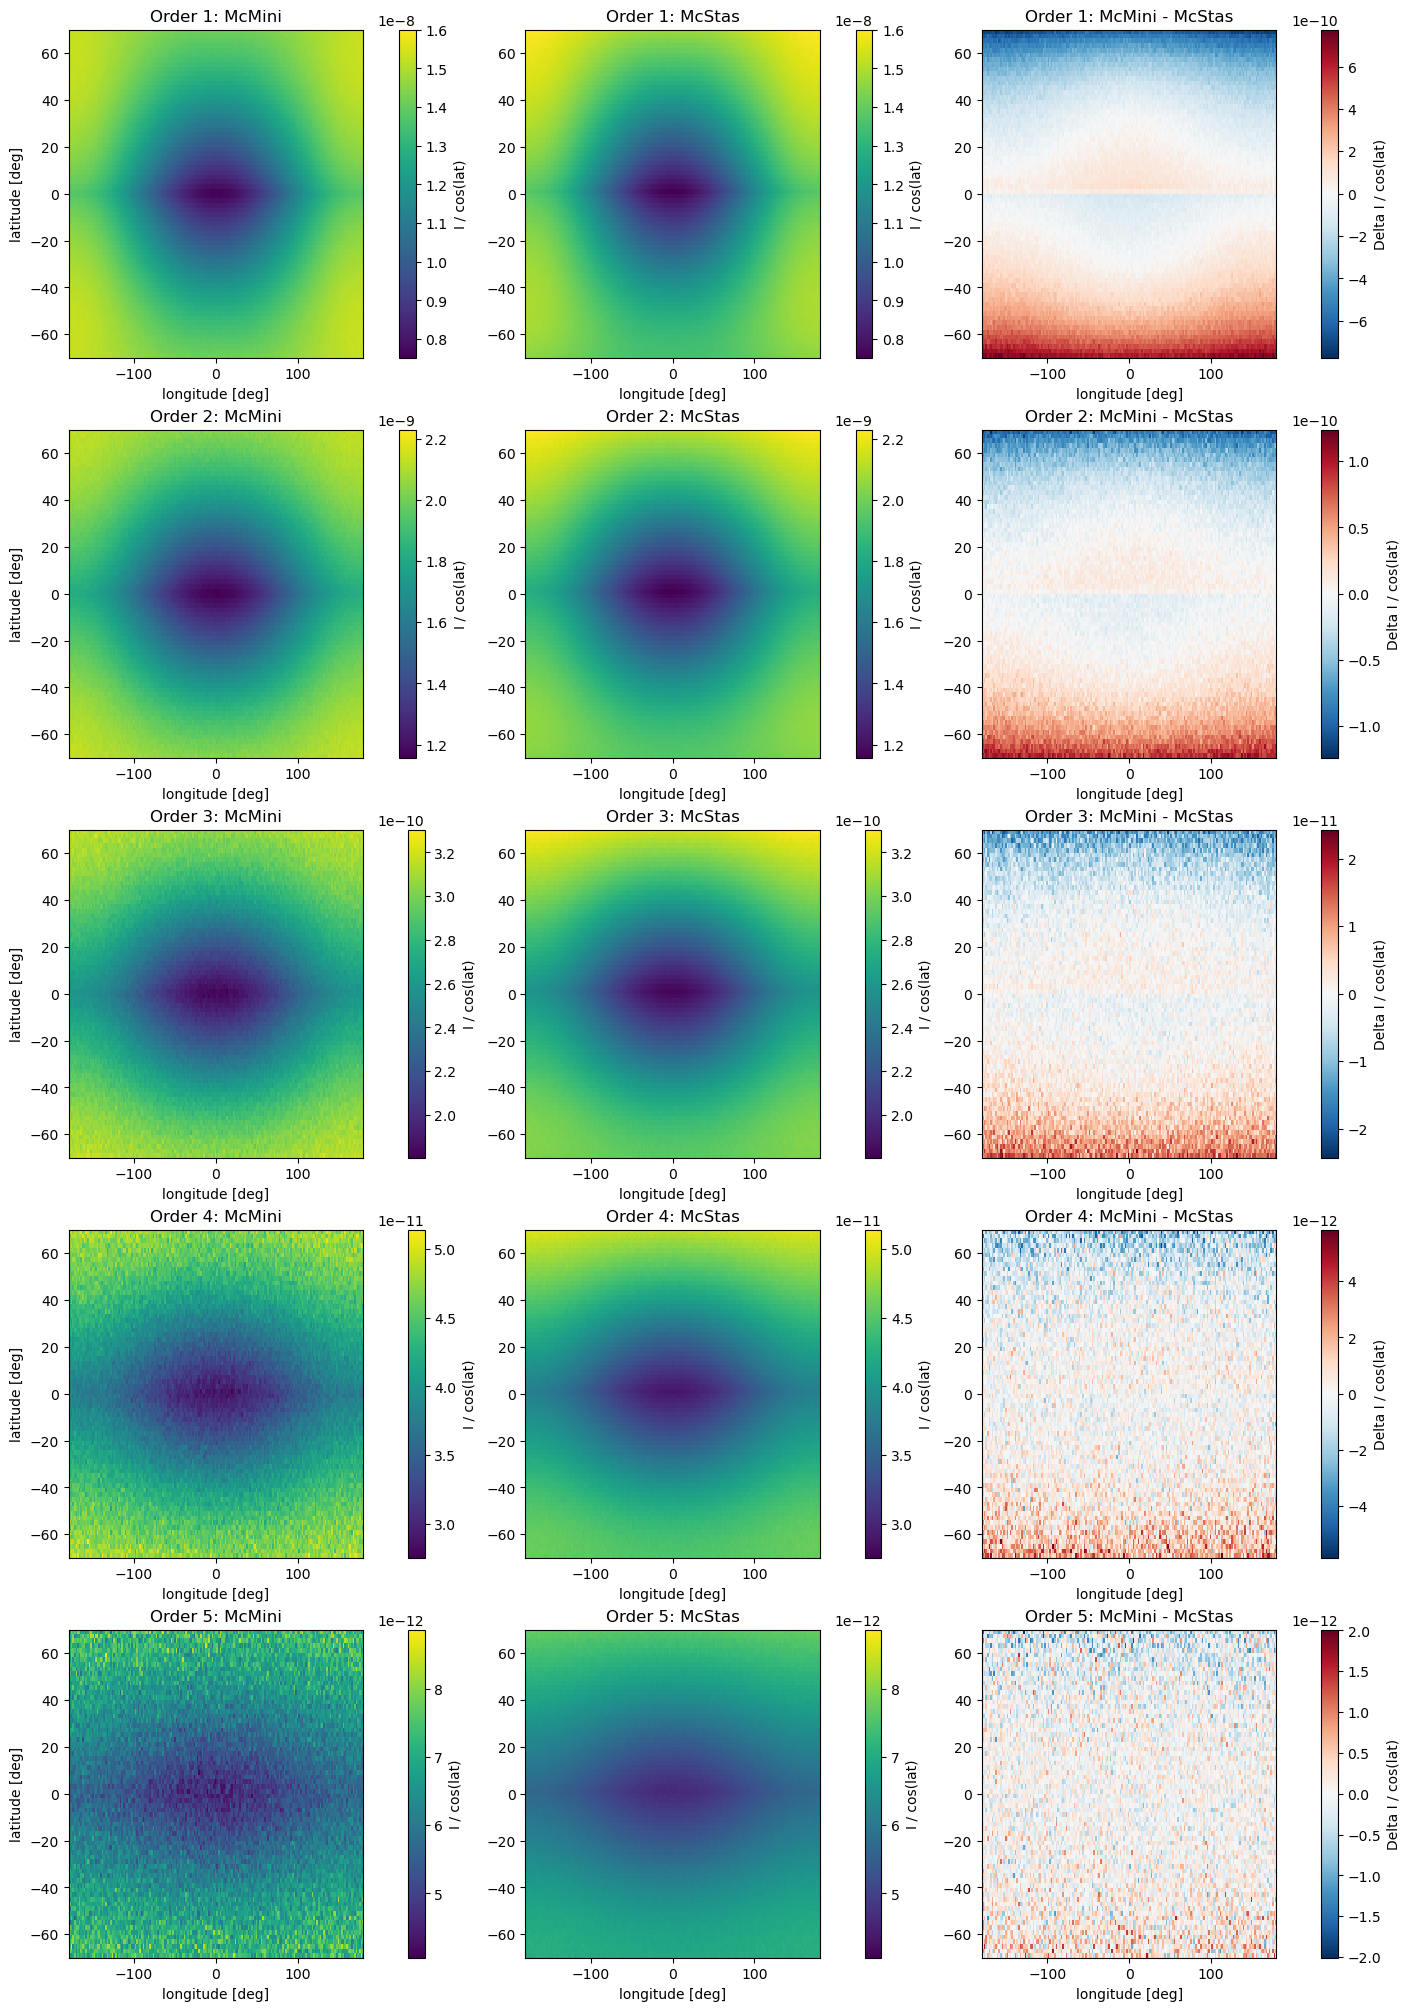

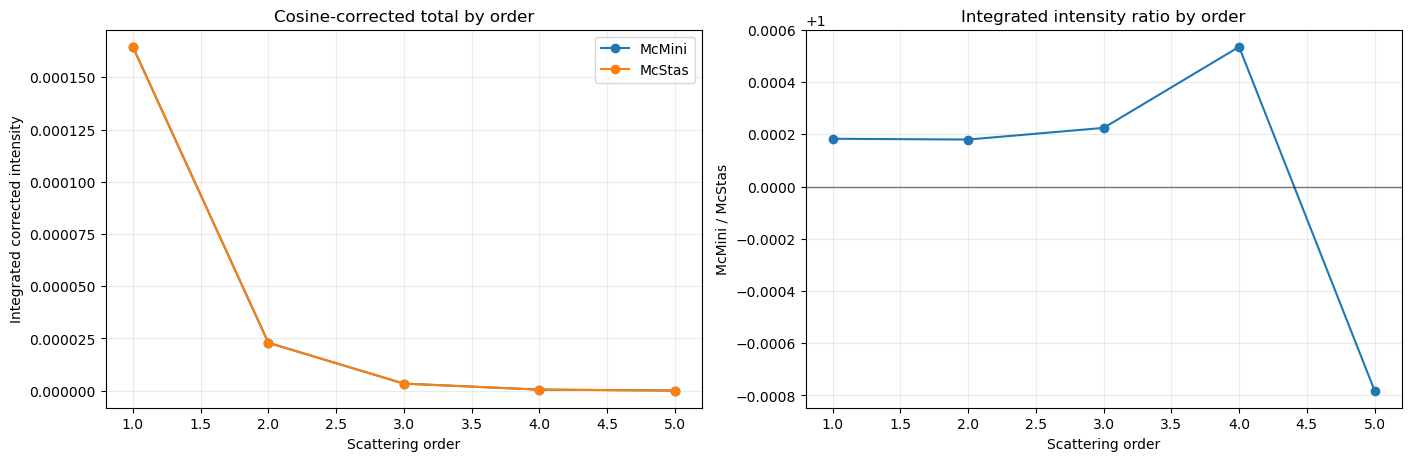

Pole cut: excluding |latitude| > 70.0 deg
order 1: McMini=1.645562e-04, share=85.93%, McStas=1.645261e-04, share=85.93%, ratio=1.000183e+00, RMS=2.605613e-10, mean pull=1.404551e-01, pull std=1.124230e+01
order 2: McMini=2.294782e-05, share=11.98%, McStas=2.294370e-05, share=11.98%, ratio=1.000180e+00, RMS=3.637636e-11, mean pull=4.671642e-02, pull std=4.555160e+00
order 3: McMini=3.396942e-06, share=1.77%, McStas=3.396179e-06, share=1.77%, ratio=1.000225e+00, RMS=5.804734e-12, mean pull=2.306552e-02, pull std=2.012388e+00
order 4: McMini=5.165557e-07, share=0.27%, McStas=5.162794e-07, share=0.27%, ratio=1.000535e+00, RMS=1.233582e-12, mean pull=8.599996e-03, pull std=1.218077e+00
order 5: McMini=7.947817e-08, share=0.04%, McStas=7.954034e-08, share=0.04%, ratio=9.992184e-01, RMS=3.806355e-13, mean pull=-3.819823e-02, pull std=1.033322e+00


In [68]:
# Cosine-corrected map comparison by scattering order: McMini vs McStas

pole_cut_deg = 20.0
mcmini_dir = Path("/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_cylinder_validation/HS_solcyl_r1mmh1mm_1e11_mcmini")
mcstas_path = "/Users/christian/Documents/Study/bachelor_project/mcmini_verification/solid_cylinder_validation/HS_solcyl_r1mmh1mm_1e11_mcstas"

lat_centers = np.linspace(-89.5, 89.5, 90)
lat_edges = np.linspace(-90.0, 90.0, len(lat_centers) + 1)
cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)
kept_lat_edges = lat_edges[np.r_[pole_mask, False] | np.r_[False, pole_mask]]
extent = [-180, 180, kept_lat_edges[0], kept_lat_edges[-1]]

mcstas_monitors = ms.load_data(mcstas_path)
order_results = []

for order in range(1, 6):
    mcmini_path = mcmini_dir / f"HS_solid_cyl_r0p5h2_scatter_{order}.csv"
    binned_data = np.loadtxt(mcmini_path, delimiter=",", comments="#")
    H_mini = binned_data[:, 2].reshape((90, 180))
    sigma_mini = binned_data[:, 3].reshape((90, 180))

    mcstas_mon = mcstas_monitors[order]
    H_mcstas = np.array(mcstas_mon.Intensity, copy=True)
    sigma_mcstas = np.array(mcstas_mon.Error, copy=True)
    meta = mcstas_mon.metadata
    if H_mcstas.shape == (meta.dimension[0], meta.dimension[1]):
        H_mcstas = H_mcstas.T
        sigma_mcstas = sigma_mcstas.T

    H_mini_corr = H_mini / np.where(cos_correction == 0, np.nan, cos_correction)
    sigma_mini_corr = sigma_mini / np.where(cos_correction == 0, np.nan, cos_correction)
    H_mcstas_corr = H_mcstas / np.where(cos_correction == 0, np.nan, cos_correction)
    sigma_mcstas_corr = sigma_mcstas / np.where(cos_correction == 0, np.nan, cos_correction)

    H_mini_corr = np.where(pole_mask[:, np.newaxis], H_mini_corr, np.nan)
    sigma_mini_corr = np.where(pole_mask[:, np.newaxis], sigma_mini_corr, np.nan)
    H_mcstas_corr = np.where(pole_mask[:, np.newaxis], H_mcstas_corr, np.nan)
    sigma_mcstas_corr = np.where(pole_mask[:, np.newaxis], sigma_mcstas_corr, np.nan)

    diff_corr = H_mini_corr - H_mcstas_corr
    sigma_combined = np.sqrt(sigma_mini_corr**2 + sigma_mcstas_corr**2)
    pull_corr = diff_corr / np.maximum(sigma_combined, 1e-30)

    order_results.append({
        "order": order,
        "mini": H_mini_corr,
        "mini_plot": H_mini_corr[pole_mask, :],
        "mcstas": H_mcstas_corr,
        "mcstas_plot": H_mcstas_corr[pole_mask, :],
        "diff": diff_corr,
        "diff_plot": diff_corr[pole_mask, :],
        "pull": pull_corr,
        "mini_total": float(np.nansum(H_mini_corr)),
        "mcstas_total": float(np.nansum(H_mcstas_corr)),
        "rms": float(np.sqrt(np.nanmean(diff_corr**2))),
        "mean_pull": float(np.nanmean(pull_corr)),
        "pull_std": float(np.nanstd(pull_corr)),
    })

fig, axs = plt.subplots(5, 3, figsize=(14, 20), constrained_layout=True)

for row, result in enumerate(order_results):
    vmin = min(np.nanmin(result["mini_plot"]), np.nanmin(result["mcstas_plot"]))
    vmax = max(np.nanmax(result["mini_plot"]), np.nanmax(result["mcstas_plot"]))
    diff_absmax = np.nanmax(np.abs(result["diff_plot"]))

    im0 = axs[row, 0].imshow(result["mini_plot"], origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
    axs[row, 0].set_title(f"Order {result['order']}: McMini")
    axs[row, 0].set_ylabel("latitude [deg]")
    fig.colorbar(im0, ax=axs[row, 0], label="I / cos(lat)")

    im1 = axs[row, 1].imshow(result["mcstas_plot"], origin="lower", extent=extent, interpolation="nearest", aspect="auto", vmin=vmin, vmax=vmax)
    axs[row, 1].set_title(f"Order {result['order']}: McStas")
    fig.colorbar(im1, ax=axs[row, 1], label="I / cos(lat)")

    im2 = axs[row, 2].imshow(result["diff_plot"], origin="lower", extent=extent, interpolation="nearest", aspect="auto", cmap="RdBu_r", vmin=-diff_absmax, vmax=diff_absmax)
    axs[row, 2].set_title(f"Order {result['order']}: McMini - McStas")
    fig.colorbar(im2, ax=axs[row, 2], label="Delta I / cos(lat)")

    for col in range(3):
        axs[row, col].set_xlabel("longitude [deg]")

plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
orders = [result["order"] for result in order_results]
mini_totals = np.array([result["mini_total"] for result in order_results])
mcstas_totals = np.array([result["mcstas_total"] for result in order_results])
mini_shares = 100.0 * mini_totals / np.sum(mini_totals)
mcstas_shares = 100.0 * mcstas_totals / np.sum(mcstas_totals)

axs[0].plot(orders, mini_totals, marker="o", lw=1.5, label="McMini")
axs[0].plot(orders, mcstas_totals, marker="o", lw=1.5, label="McStas")
axs[0].set_xlabel("Scattering order")
axs[0].set_ylabel("Integrated corrected intensity")
axs[0].set_title("Cosine-corrected total by order")
axs[0].grid(alpha=0.25)
axs[0].legend()

axs[1].plot(orders, mini_totals / mcstas_totals, marker="o", lw=1.5)
axs[1].axhline(1.0, color="k", lw=1.0, alpha=0.5)
axs[1].set_xlabel("Scattering order")
axs[1].set_ylabel("McMini / McStas")
axs[1].set_title("Integrated intensity ratio by order")
axs[1].grid(alpha=0.25)

plt.show()

print(f"Pole cut: excluding |latitude| > {90.0 - pole_cut_deg:.1f} deg")
for result in order_results:
    order_idx = result['order'] - 1
    print(
        f"order {result['order']}: "
        f"McMini={result['mini_total']:.6e}, "
        f"share={mini_shares[order_idx]:.2f}%, "
        f"McStas={result['mcstas_total']:.6e}, "
        f"share={mcstas_shares[order_idx]:.2f}%, "
        f"ratio={result['mini_total'] / result['mcstas_total']:.6e}, "
        f"RMS={result['rms']:.6e}, "
        f"mean pull={result['mean_pull']:.6e}, "
        f"pull std={result['pull_std']:.6e}"
    )
